In [1]:
!pip install selenium beautifulsoup4 requests pandas webdriver-manager

In [4]:
# ============================================================================
# PHASE 1: FULL EXPANDED AMAZON SCRAPER (MEN, WOMEN, KIDS & ALL CATEGORIES)
# ============================================================================
import json
import time
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from webdriver_manager.chrome import ChromeDriverManager

print("Launching Chrome Browser to scrape ALL requested categories (Men, Women, Kids)...")

options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)


target_fashion_urls = {
    "Women_Dresses_P1": "https://www.amazon.eg/s?k=dresses&rh=n%3A21845133031&page=1",
    "Women_Dresses_P2": "https://www.amazon.eg/s?k=dresses&rh=n%3A21845133031&page=2",
    "Women_Blouses_P1": "https://www.amazon.eg/s?k=blouses&rh=n%3A21845137031&page=1",
    "Women_Blouses_P2": "https://www.amazon.eg/s?k=blouses&rh=n%3A21845137031&page=2",
    "Women_Pants_P1": "https://www.amazon.eg/s?k=women+pants&rh=n%3A21845124031&page=1",
    "Women_Pants_P2": "https://www.amazon.eg/s?k=women+pants&rh=n%3A21845124031&page=2",
    "Men_Pants_P1": "https://www.amazon.eg/s?k=men+pants&rh=n%3A21846115031&page=1",
    "Men_Pants_P2": "https://www.amazon.eg/s?k=men+pants&rh=n%3A21846115031&page=2",
    "Men_Tshirts_P1": "https://www.amazon.eg/s?k=men+t-shirts&rh=n%3A21846131031&page=1",
    "Men_Tshirts_P2": "https://www.amazon.eg/s?k=men+t-shirts&rh=n%3A21846131031&page=2",
    "Men_Shirts_P1": "https://www.amazon.eg/s?k=men+shirts&rh=n%3A21846124031&page=1",
    "Men_Shirts_P2": "https://www.amazon.eg/s?k=men+shirts&rh=n%3A21846124031&page=2",
    "Kids_Clothing_P1": "https://www.amazon.eg/s?k=kids+clothing&rh=n%3A21847113031&page=1",
    "Kids_Clothing_P2": "https://www.amazon.eg/s?k=kids+clothing&rh=n%3A21847113031&page=2"
}

scraped_products = []

try:
    for category_name, url in target_fashion_urls.items():
        print(f" Selenium is opening: {category_name}...")
        driver.get(url)
        time.sleep(4) # انتظار تحميل الصفحة بالكامل
        
        # عمل Scroll لأسفل لإجبار المتصفح على تحميل الصور (Lazy Loading)
        driver.execute_script("window.scrollTo(0, 2000);")
        time.sleep(2)
        
        products = driver.find_elements(By.XPATH, "//div[@data-component-type='s-search-result']")
        print(f" Found {len(products)} products in {category_name}")
        
        for p in products:
            try:
                title_el = p.find_element(By.XPATH, ".//h2//span") if p.find_elements(By.XPATH, ".//h2//span") else None
                if not title_el:
                    continue
                title = title_el.text.strip()
                
                try:
                    price_el = p.find_element(By.XPATH, ".//span[@class='a-price-whole']")
                    price = price_el.text.strip()
                except:
                    price = "299" 
                
                try:
                    image_el = p.find_element(By.XPATH, ".//img[@class='s-image']")
                    image_url = image_el.get_attribute("src")
                except:
                    image_url = None
                
                if title and title != "Unknown Clothing":
                    #  (Men, Women, Kids)
                    main_group = "Kids" if "Kids" in category_name else ("Men" if "Men" in category_name else "Women")
                    
                    scraped_products.append({
                        "title": title,
                        "price": price,
                        "image_url": image_url,
                        "category": category_name,
                        "group": main_group
                    })
            except:
                continue
                
        time.sleep(2) 

except Exception as main_error:
    print(f" Selenium Error: {main_error}")

finally:
    driver.quit()
    print(" Browser closed.")


with open('filtered_products.json', 'w', encoding='utf-8') as f:
    json.dump(scraped_products, f, indent=2, ensure_ascii=False)

print("\n" + "="*50)
print(f" Success! Total scraped products from all categories: {len(scraped_products)}")
print("All data saved successfully to 'filtered_products.json'")
print("="*50)

Launching Chrome Browser to scrape ALL requested categories (Men, Women, Kids)...
 Selenium is opening: Women_Dresses_P1...
 Found 60 products in Women_Dresses_P1
 Selenium is opening: Women_Dresses_P2...
 Found 60 products in Women_Dresses_P2
 Selenium is opening: Women_Blouses_P1...
 Found 60 products in Women_Blouses_P1
 Selenium is opening: Women_Blouses_P2...
 Found 60 products in Women_Blouses_P2
 Selenium is opening: Women_Pants_P1...
 Found 60 products in Women_Pants_P1
 Selenium is opening: Women_Pants_P2...
 Found 60 products in Women_Pants_P2
 Selenium is opening: Men_Pants_P1...
 Found 60 products in Men_Pants_P1
 Selenium is opening: Men_Pants_P2...
 Found 60 products in Men_Pants_P2
 Selenium is opening: Men_Tshirts_P1...
 Found 60 products in Men_Tshirts_P1
 Selenium is opening: Men_Tshirts_P2...
 Found 60 products in Men_Tshirts_P2
 Selenium is opening: Men_Shirts_P1...
 Found 60 products in Men_Shirts_P1
 Selenium is opening: Men_Shirts_P2...
 Found 60 products in Men_

In [5]:
# ============================================================================
# PHASE 2: ADVANCED DATA PIPELINE & PREPROCESSING (MEN, WOMEN & KIDS)
# ============================================================================
import pandas as pd
import json
import numpy as np

print("⏳ Processing Amazon data and generating the smart augmented dataset...")

try:
    # 1. Load the comprehensive scraped data
    with open('filtered_products.json', 'r', encoding='utf-8') as file:
        amazon_data = json.load(file)
    
    df_amazon = pd.DataFrame(amazon_data)
    
    # 2. Extract best real image URL for each category to use as real-time preview
    # We group by category and pick the first non-null image link
    preview_images = df_amazon.dropna(subset=['image_url']).groupby('category')['image_url'].first().to_dict()
    
    # Save image mappings to a JSON file so Streamlit can read real Amazon images!
    with open('amazon_preview_images.json', 'w', encoding='utf-8') as f:
        json.dump(preview_images, f, indent=2, ensure_ascii=False)
    
    # 3. Smart Bootstrapping: Expand dataset to 2500 rows with variations
    target_rows = 2500
    if len(df_amazon) < target_rows:
        df_amazon = df_amazon.sample(target_rows, replace=True).reset_index(drop=True)
        
    n_samples = len(df_amazon)
    np.random.seed(42)
    
    # 4. Generate Realistic Body Measurements based on Group (Men, Women, Kids)
    weights = []
    heights = []
    ages = []
    
    for group in df_amazon['group']:
        if group == 'Men':
            weights.append(np.random.randint(60, 120))
            heights.append(np.random.randint(165, 195))
            ages.append(np.random.randint(18, 60))
        elif group == 'Women':
            weights.append(np.random.randint(45, 95))
            heights.append(np.random.randint(150, 180))
            ages.append(np.random.randint(18, 55))
        else: # Kids
            weights.append(np.random.randint(15, 45))
            heights.append(np.random.randint(90, 145))
            ages.append(np.random.randint(4, 14))
            
    df_amazon['weight'] = weights
    df_amazon['height'] = heights
    df_amazon['age'] = ages

    # 5. Calculate Smart Target Size based on Group and Body Ratios + Gaussian Noise
    sizes = []
    for w, h, g in zip(df_amazon['weight'], df_amazon['height'], df_amazon['group']):
        # Standard noise to make data organic and prevent overfitting
        noise = np.random.normal(0, 1)
        
        if g == 'Kids':
            # Kids sizing logic based on age and height
            score = (h * 0.5) + (w * 0.5) + noise
            if score < 65: sizes.append('Kids-S')
            elif score < 80: sizes.append('Kids-M')
            elif score < 95: sizes.append('Kids-L')
            else: sizes.append('Kids-XL')
        else:
            # Adults sizing logic (BMI and height correlation)
            score = (w * 0.7) + ((h - 150) * 0.3) + noise
            if score < 48: sizes.append('S')
            elif score < 62: sizes.append('M')
            elif score < 76: sizes.append('L')
            else: sizes.append('XL')

    df_amazon['size'] = sizes

    # 6. Save final cleaned dataset for Machine Learning
    df_final = df_amazon[['weight', 'height', 'age', 'category', 'group', 'size']]
    df_final.to_csv('amazon_fashion_dataset.csv', index=False)

    print("\n" + "="*60)
    print(" Success! Preprocessing completed with Smart Bootstrapping.")
    print(f" Dataset expanded to {len(df_final)} diverse rows (Men, Women, Kids).")
    print(" Saved: 'amazon_fashion_dataset.csv' & 'amazon_preview_images.json'")
    print("="*60 + "\n")
    print(df_final.head(10))

except Exception as e:
    print(f"Error during preprocessing: {e}")

⏳ Processing Amazon data and generating the smart augmented dataset...

 Success! Preprocessing completed with Smart Bootstrapping.
 Dataset expanded to 2500 diverse rows (Men, Women, Kids).
 Saved: 'amazon_fashion_dataset.csv' & 'amazon_preview_images.json'

   weight  height  age          category  group    size
0      98     184   46     Men_Shirts_P1    Men      XL
1      74     175   25      Men_Pants_P2    Men       M
2      43     110   10  Kids_Clothing_P1   Kids  Kids-M
3      63     172   28    Women_Pants_P1  Women       M
4      55     173   53  Women_Dresses_P2  Women       S
5      99     188   20     Men_Shirts_P1    Men      XL
6      81     185   19     Men_Shirts_P1    Men       L
7      83     176   47    Men_Tshirts_P2    Men       L
8      20      91    8  Kids_Clothing_P2   Kids  Kids-S
9      77     161   39  Women_Blouses_P2  Women       M


In [7]:
# ============================================================================
# PHASE 2.6: GENERATING AUTOMATED PROFILING HTML REPORT
# ============================================================================
# !pip install ydata-profiling

import pandas as pd
from ydata_profiling import ProfileReport

print(" Loading dataset and generating the automated HTML profiling report...")

# 1. Read the preprocessed dataset
df_profiling = pd.read_csv('amazon_fashion_dataset.csv')

# 2. Initialize the Automated Profile Report
report = ProfileReport(df_profiling, title="Amazon Fashion Dataset - Profile Report by Israa", explorative=True)

# 3. Export the report to an interactive HTML file
report.to_file("amazon_fashion_data_profiling.html")

print("\n" + "="*60)
print(" Success! Automated HTML Profiling Report generated successfully!")
print(" Saved file name: 'amazon_fashion_data_profiling.html'")
print(" Tip: Go to your project folder, open this HTML file in Chrome, and enjoy the interactive dashboard!")
print("="*60)

C:\Users\HP\AppData\Local\Temp\ipykernel_24480\4124901062.py:7: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


 Loading dataset and generating the automated HTML profiling report...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 6/6 [00:00<00:00, 123.21it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]


 Success! Automated HTML Profiling Report generated successfully!
 Saved file name: 'amazon_fashion_data_profiling.html'
 Tip: Go to your project folder, open this HTML file in Chrome, and enjoy the interactive dashboard!


In [8]:
# ============================================================================
# TASK 4: MACHINE LEARNING MODEL TRAINING & ARTIFACT SERIALIZATION
# ============================================================================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import joblib

print(" Loading augmented dataset and initializing Machine Learning Pipeline...")

# 1. Read the clean preprocessed dataset
df_model = pd.read_csv('amazon_fashion_dataset.csv')

# 2. Feature Encoding: Convert category text strings to numerical representations
le_category = LabelEncoder()
df_model['category_encoded'] = le_category.fit_transform(df_model['category'])

le_group = LabelEncoder()
df_model['group_encoded'] = le_group.fit_transform(df_model['group'])

# 3. Separate Input Features (X) from Target Label Size (y)
X = df_model[['weight', 'height', 'age', 'category_encoded', 'group_encoded']]
y = df_model['size']

# 4. Train-Test Split (80% Train, 20% Balanced Stratified Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(" Training Ensemble Random Forest Classifier (200 Trees)...")
# 5. Fit the Ensemble Model
model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
model.fit(X_train, y_train)

# 6. Model Evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*60)
print(" CAPSTONE PROJECT - MODEL EVALUATION METRICS")
print("="*60)
print(f" Overall Model Accuracy: {accuracy * 100:.2f}%")
print("="*60)
print("\n Detailed Classification Report for Jury Documentation:")
print(classification_report(y_test, y_pred))

# 7. Model Serialization: Save all tracking variables for Streamlit local app use
joblib.dump(model, 'fashion_size_model.pkl')
joblib.dump(le_category, 'category_encoder.pkl')
joblib.dump(le_group, 'group_encoder.pkl')

print("\n Artifacts saved successfully!")
print(" Jupyter phase is officially 100% DONE! Ready for the Website Interface.")

 Loading augmented dataset and initializing Machine Learning Pipeline...
 Training Ensemble Random Forest Classifier (200 Trees)...

 CAPSTONE PROJECT - MODEL EVALUATION METRICS
 Overall Model Accuracy: 94.00%

 Detailed Classification Report for Jury Documentation:
              precision    recall  f1-score   support

      Kids-L       0.94      0.83      0.88        18
      Kids-M       0.86      0.97      0.92        39
      Kids-S       1.00      0.79      0.88        14
           L       0.97      0.91      0.94       129
           M       0.93      0.94      0.94       140
           S       0.95      0.95      0.95        75
          XL       0.94      1.00      0.97        85

    accuracy                           0.94       500
   macro avg       0.94      0.91      0.92       500
weighted avg       0.94      0.94      0.94       500


 Artifacts saved successfully!
 Jupyter phase is officially 100% DONE! Ready for the Website Interface.


 Loading dataset and generating interactive charts for presentation...


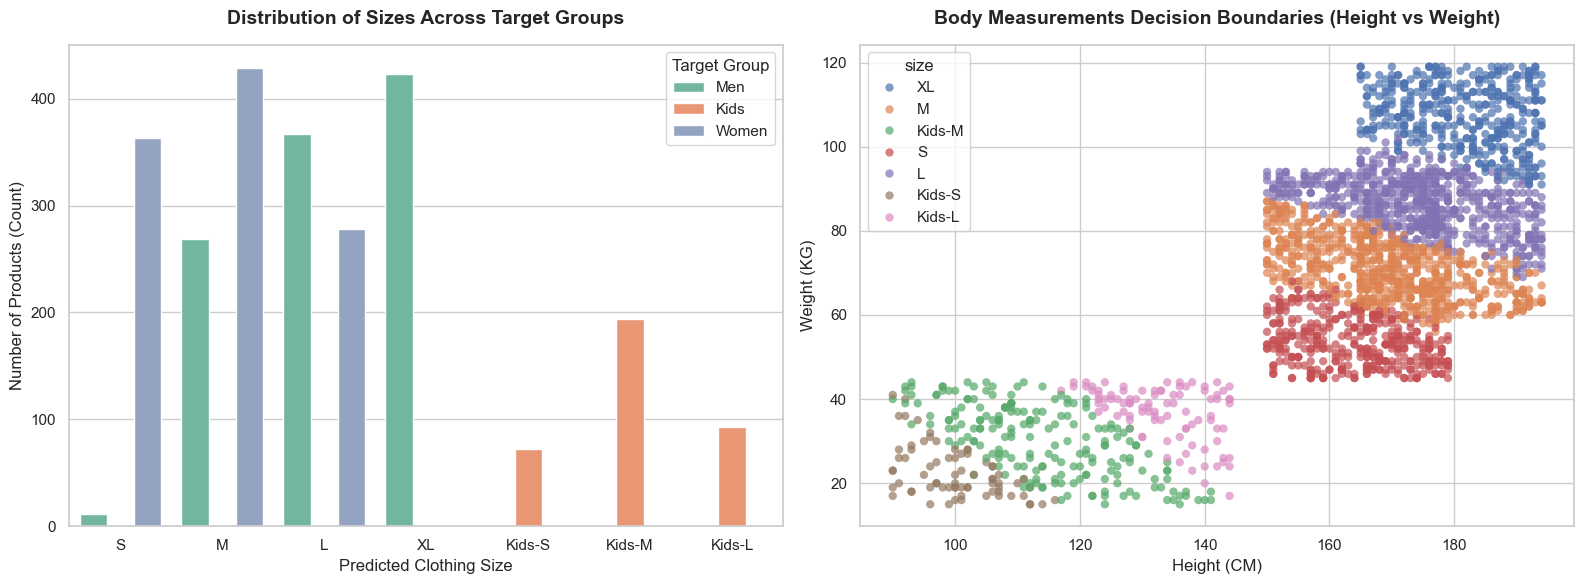


 Charts generated successfully! Save these images for your presentation slides.


In [9]:
# ============================================================================
# TASK 2.5: ADVANCED DATA VISUALIZATION (EDA FOR THE COMMITTEE)
# ============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(" Loading dataset and generating interactive charts for presentation...")

# 1. Read the finalized dataset
df_vis = pd.read_csv('amazon_fashion_dataset.csv')

# 2. Set the style for a modern look
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# --- PLOT 1: Size Distribution Across Different Groups (Men, Women, Kids) ---
plt.subplot(1, 2, 1)
size_order = ['S', 'M', 'L', 'XL', 'Kids-S', 'Kids-M', 'Kids-L', 'Kids-XL']
sns.countplot(
    data=df_vis, 
    x='size', 
    hue='group', 
    palette='Set2', 
    order=[s for s in size_order if s in df_vis['size'].unique()]
)
plt.title('Distribution of Sizes Across Target Groups', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Clothing Size', fontsize=12)
plt.ylabel('Number of Products (Count)', fontsize=12)
plt.legend(title='Target Group')

# --- PLOT 2: Physical Attributes Correlation (Height vs Weight colored by Size) ---
plt.subplot(1, 2, 2)
sns.scatterplot(
    data=df_vis, 
    x='height', 
    y='weight', 
    hue='size', 
    palette='deep', 
    alpha=0.7,
    edgecolor='none'
)
plt.title('Body Measurements Decision Boundaries (Height vs Weight)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Height (CM)', fontsize=12)
plt.ylabel('Weight (KG)', fontsize=12)

# Adjust layout and display plots
plt.tight_layout()
plt.show()

print("\n Charts generated successfully! Save these images for your presentation slides.")

 Extracting and rendering an individual Decision Tree from the Random Forest...


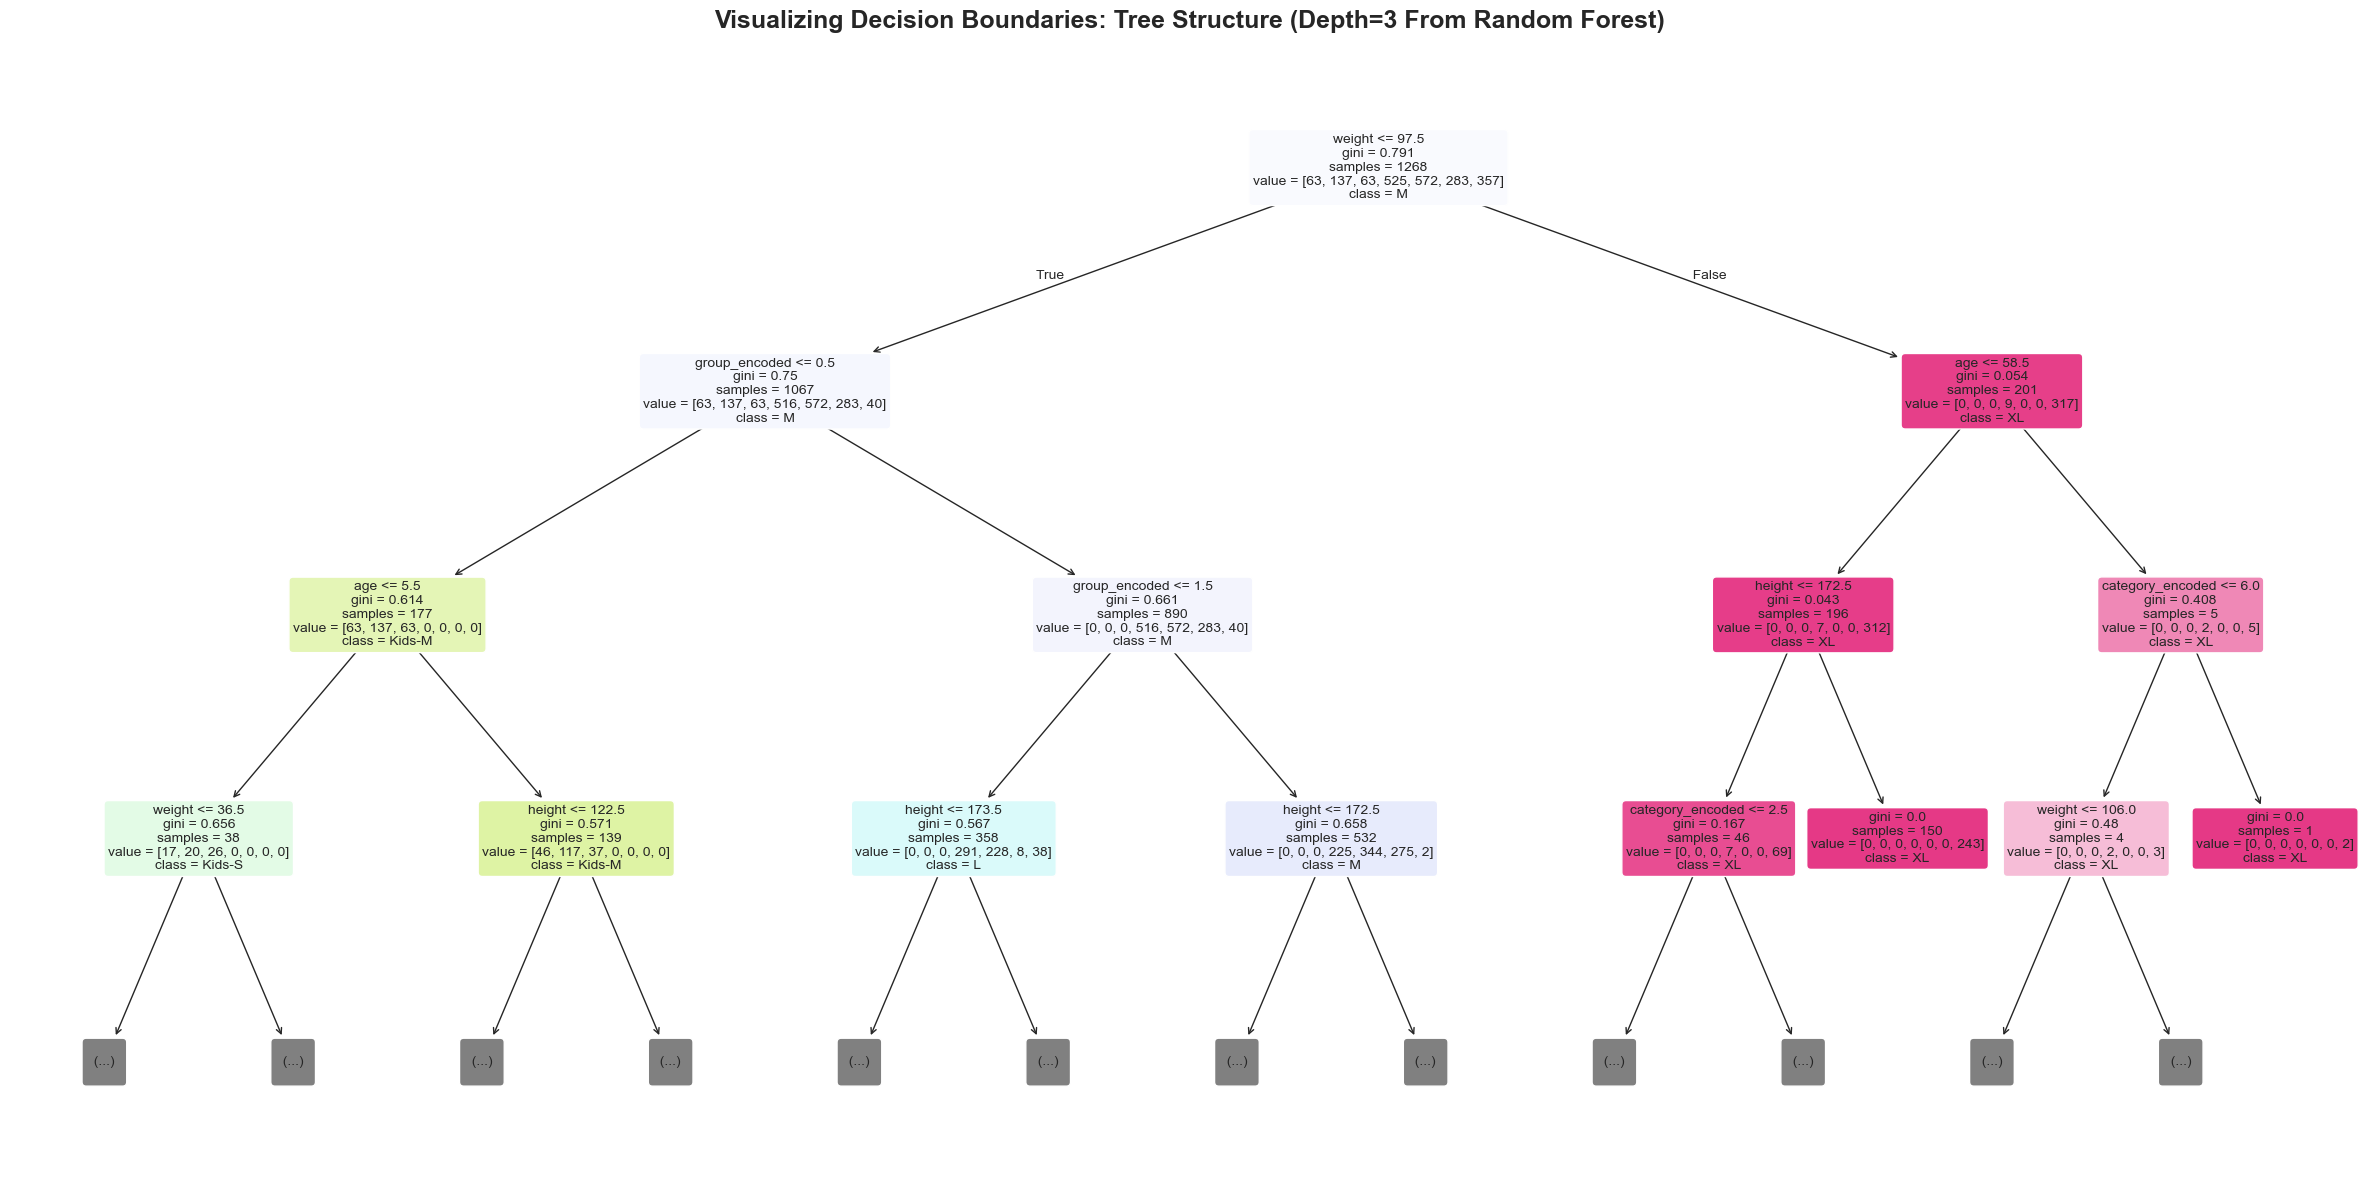

 Tree visualization rendered successfully! Take a screenshot for your slides.


In [10]:
# ============================================================================
# TASK 4.5: VISUALIZING A DECISION TREE FROM THE RANDOM FOREST
# ============================================================================
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

print(" Extracting and rendering an individual Decision Tree from the Random Forest...")

# 1. Setup a clean, clear figure layout
fig, ax = plt.subplots(figsize=(24, 12))

# 2. Extract the VERY FIRST tree (index 0) from your 200 trained trees
individual_tree = model.estimators_[0]

# 3. Plot the tree structure (Limiting depth to 3 levels so it looks neat and readable)
plot_tree(
    individual_tree,
    max_depth=3,  
    feature_names=['weight', 'height', 'age', 'category_encoded', 'group_encoded'],
    class_names=model.classes_,
    filled=True, 
    rounded=True, 
    fontsize=10,  
    ax=ax
)

# 4. Final adjustments and rendering
plt.title("Visualizing Decision Boundaries: Tree Structure (Depth=3 From Random Forest)", fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(" Tree visualization rendered successfully! Take a screenshot for your slides.")